### Importation des librairies 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import csv
import os
import pickle
from matplotlib.ticker import MultipleLocator
import xarray as xr

Matplotlib is building the font cache; this may take a moment.


### Importation des fichiers 3D

In [3]:
data_cli = xr.open_dataset("3D/MESONH_RCE_small300_3D_cli.nc") #glace nuageuse
data_clw = xr.open_dataset("3D/MESONH_RCE_small300_3D_clw.nc") #eau liquide nuageuse
data_hur = xr.open_dataset("3D/MESONH_RCE_small300_3D_hur.nc") #humidité relative
data_hus = xr.open_dataset("3D/MESONH_RCE_small300_3D_hus.nc") #humidité spécifique
data_pa = xr.open_dataset("3D/MESONH_RCE_small300_3D_pa.nc") #pression atmosphérique 
data_pli = xr.open_dataset("3D/MESONH_RCE_small300_3D_pli.nc") #glace précipitante
data_plw = xr.open_dataset("3D/MESONH_RCE_small300_3D_plw.nc") #eau liquide précipitante
data_ta = xr.open_dataset("3D/MESONH_RCE_small300_3D_ta.nc") #température atmosphérique
data_tntr = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntr.nc") #tendance des températures(radiative)
data_tntrl = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrl.nc") #tendance des températures(radiative longwave)
data_tntrs = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrs.nc") #tendance des températures(radiative shortwave)
data_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc") #vitesse de l air
data_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc") #vitesse de l air
data_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc") #vitesse de l air verticale

In [41]:
print(data_clw)
print(data_tntr)
print(data_ua)

<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    clw       (time, altitude, y, x) float32 296MB ...
<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    tntr      (time, altitude, y, x) float32 296MB ...
<xarray.Dataset> Size: 296MB

On a une grille horizontale de 100 par 100. L'altitude est découpée en 74 couches et le modèle a enregistré 100 moments différents.

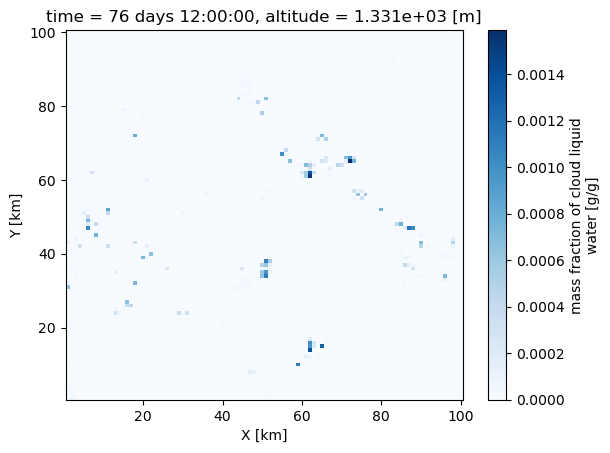

In [5]:
data_clw['clw'].isel(time=5, altitude=10).plot(cmap = 'Blues')

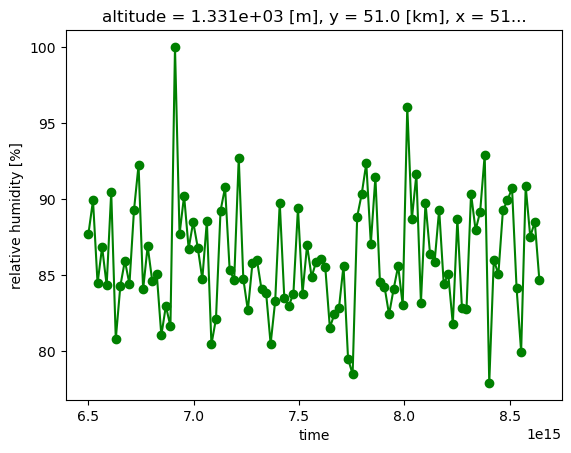

In [6]:
data_hur['hur'].isel(x=50, y=50, altitude=10).plot(marker='o', color='green')

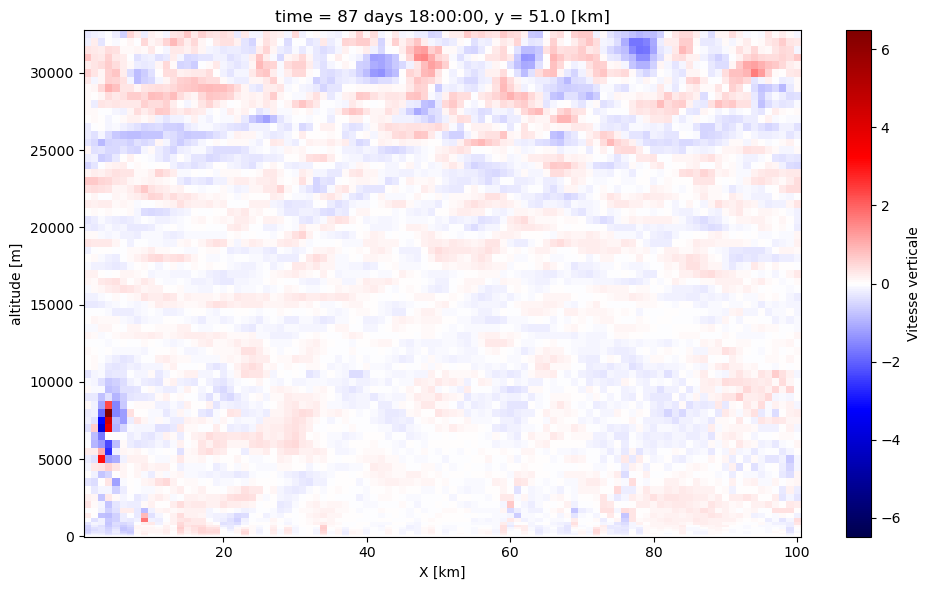

In [7]:
time_index = 50
y_index = 50
coupe_verticale_wa = data_wa['wa'].isel(time=time_index, y=y_index)
plt.figure(figsize=(10,6))
plot = coupe_verticale_wa.plot(x='x', y='altitude', cmap='seismic', cbar_kwargs={'label':'Vitesse verticale'})
plt.tight_layout()
plt.show()

### Exemple 1D

In [8]:
data_clw_1D = xr.open_dataset("1D/MESONH_RCE_small300_1D_clw_avg.nc") #eau liquide nuageuse
print(data_clw_1D)

<xarray.Dataset> Size: 730kB
Dimensions:   (time: 2400, altitude: 74)
Coordinates:
  * time      (time) timedelta64[ns] 19kB 01:00:00.000107285 ... 100 days 00:...
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
Data variables:
    clw_avg   (time, altitude) float32 710kB ...


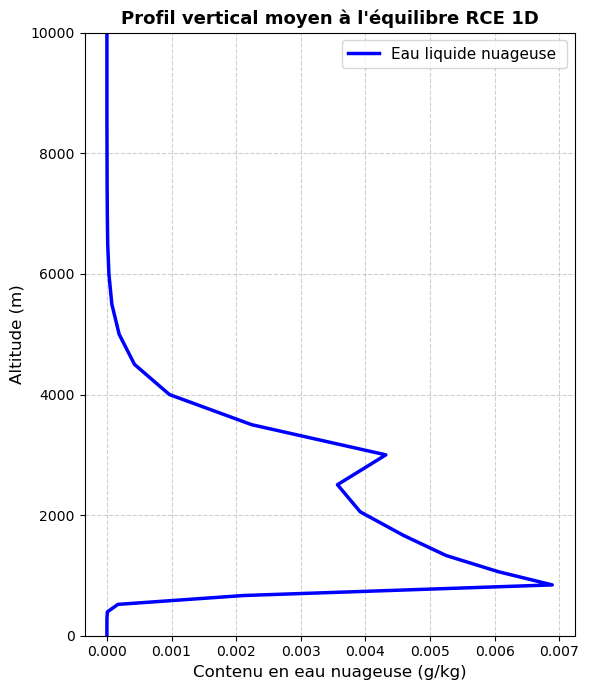

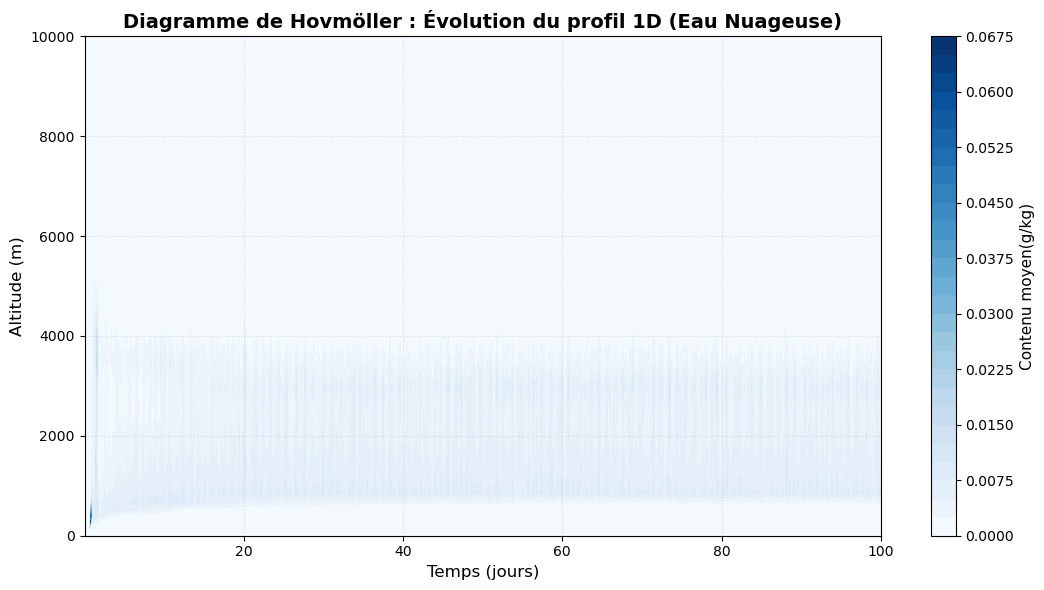

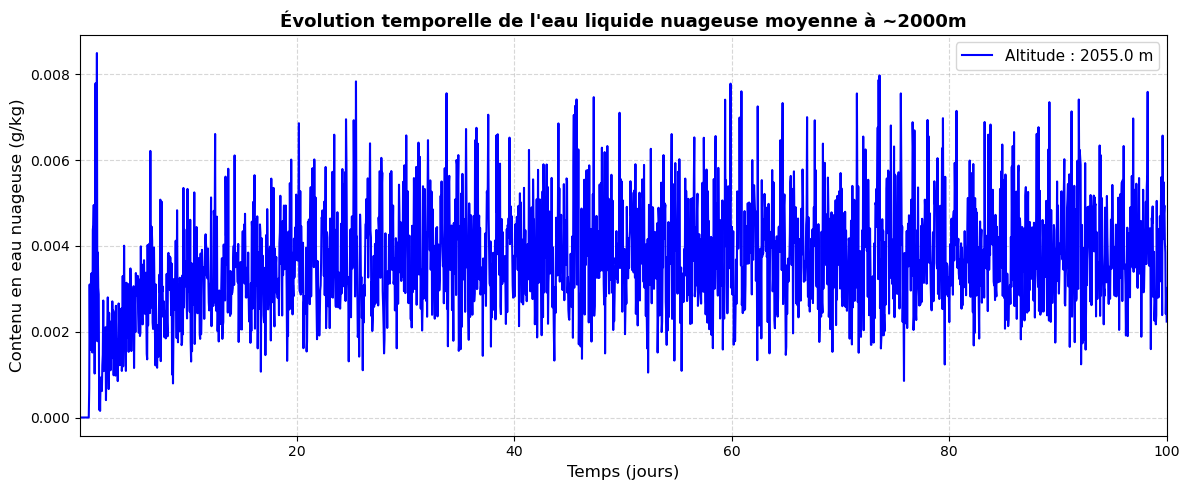

In [9]:
# Extraction de la variable de l'eau liquide nuageuse 
clw_1d = data_clw_1D['clw_avg']

# état stationnaire ou l'équilibre final, 20 derniers pas de temps 
clw_equilibrium = clw_1d.isel(time=slice(-200, None)).mean(dim='time')

# =============================================================================
# REPRÉSENTATION DU PROFIL VERTICAL MOYEN (ÉQUILIBRE)
# =============================================================================
plt.figure(figsize=(6, 7))

# Multiplication par 1000 pour convertir les kg/kg de l'eau nuageuse en g/kg
plt.plot(clw_equilibrium * 1000, clw_1d.altitude, color='blue', lw=2.5, label=r'Eau liquide nuageuse ')

plt.xlabel('Contenu en eau nuageuse (g/kg)', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.title('Profil vertical moyen à l\'équilibre RCE 1D', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.ylim(0, 10000)
plt.tight_layout()
plt.show()

# =============================================================================
# DIAGRAMME DE HOVMÖLLER (ÉVOLUTION TEMPORELLE DU PROFIL 1D)
# =============================================================================

plt.figure(figsize=(11, 6))

# Conversion de l'axe du temps (timedelta64[ns]) en jours 
temps_jours = clw_1d.time.astype('float64') / (1e9 * 3600 * 24)

# Génération des contours remplis (Axe X : Temps, Axe Y : Altitude)
cf = plt.contourf(temps_jours, clw_1d.altitude, clw_1d.T * 1000, levels=30, cmap='Blues')

# Ajout de la barre d'échelle des couleurs
cb = plt.colorbar(cf)
cb.set_label('Contenu moyen(g/kg)', fontsize=11)

plt.xlabel('Temps (jours)', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.title('Diagramme de Hovmöller : Évolution du profil 1D (Eau Nuageuse)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.4)
plt.ylim(0, 10000)
plt.tight_layout()
plt.show()



# =============================================================================
# TRACÉ DE L'ÉVOLUTION TEMPORELLE (JOUR APRÈS JOUR)
# =============================================================================
# Sélection de la couche la plus proche de 2000 mètres (méthode 'nearest')
clw_2000m = clw_1d.sel(altitude=2000, method='nearest')

altitude_exacte = float(clw_2000m.altitude)
temps_jours = clw_1d.time.astype('float64') / (1e9 * 3600 * 24)

plt.figure(figsize=(12, 5))

# Multiplication par 1000 pour convertir les kg/kg en g/kg
plt.plot(temps_jours, clw_2000m.values * 1000, color='blue', lw=1.5, label=f'Altitude : {altitude_exacte:.1f} m')

plt.xlabel('Temps (jours)', fontsize=12)
plt.ylabel('Contenu en eau nuageuse (g/kg)', fontsize=12)
plt.title(f'Évolution temporelle de l\'eau liquide nuageuse moyenne à ~2000m', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Ajustement automatique des limites de l'axe X pour couvrir toute la simulation
plt.xlim(temps_jours.min(), temps_jours.max())

plt.tight_layout()
plt.show()

### Tracé du flux  de quantité de mouvement et de sa dérivée 

Chargement des fichiers NetCDF...
Données chargées avec succès.
Forme des fichiers : (100, 74, 100, 100) (Temps, Altitude, Y, X)
Calcul des moyennes horizontales et des anomalies (primes)...
Calcul des flux de Reynolds...
altitude
Moyenne temporelle finale...
Génération des graphiques...


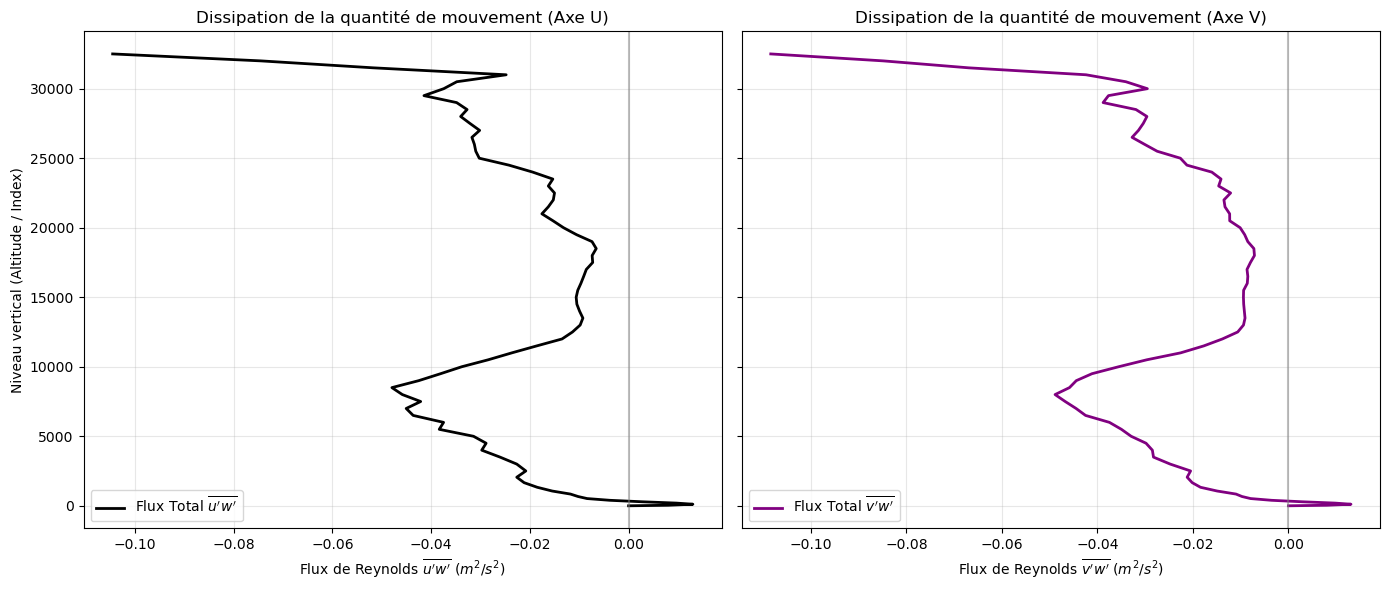

In [10]:
# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================
print("Chargement des fichiers NetCDF...")

# Chargement des vents (U: zonal, V: méridien, W: vertical)
ds_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc")
ds_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc")
ds_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc")

# Extraction des DataArrays spécifiques 
u = ds_ua["ua"]
v = ds_va["va"]
w = ds_wa["wa"]

print("Données chargées avec succès.")
print(f"Forme des fichiers : {u.shape} (Temps, Altitude, Y, X)")

# =============================================================================
# 2. DÉCOMPOSITION DE REYNOLDS (Calcul des moyennes et des anomalies)
# =============================================================================
print("Calcul des moyennes horizontales et des anomalies (primes)...")

# Étape A: Calcul de la moyenne horizontale sur les axes 'x' et 'y'
# L'état moyen dépend uniquement du temps (time) et de la hauteur (level/altitude)
u_mean = u.mean(dim=["x", "y"])
v_mean = v.mean(dim=["x", "y"])
w_mean = w.mean(dim=["x", "y"])

# Étape B: Calcul des fluctuations turbulentes (Anomalies = Valeur - Moyenne)
u_prime = u - u_mean
v_prime = v - v_mean
w_prime = w - w_mean

# =============================================================================
# 3. CALCUL DES FLUX TURBULENTS DE QUANTITÉ DE MOUVEMENT
# =============================================================================
print("Calcul des flux de Reynolds...")

# Flux instantanés en chaque point de la grille 3D
flux_u_3d = u_prime * w_prime
flux_v_3d = v_prime * w_prime

# Flux total moyen (moyenne horizontale)
# On obtient un profil vertical qui évolue au cours du temps
flux_u_total_profile = flux_u_3d.mean(dim=["x", "y"])
flux_v_total_profile = flux_v_3d.mean(dim=["x", "y"])

print(u.dims[1])

# =============================================================================
# 5. MOYENNE TEMPORELLE ET EXTRACTION DE L'ALTITUDE
# =============================================================================
print("Moyenne temporelle finale...")

# On fait la moyenne sur tout le contenu temporel pour avoir le comportement stationnaire
flux_u_total_final = flux_u_total_profile.mean(dim="time")
flux_v_total_final = flux_v_total_profile.mean(dim="time")

axe_z = u["altitude"].values

# =============================================================================
# 6. VISUALISATION DES RÉSULTATS (TRACÉ DES PROFILS VERTICAUX)
# =============================================================================
print("Génération des graphiques...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Graphique 1 : Profils de flux pour la composante U (Zonale)
ax1.plot(
    flux_u_total_final,
    axe_z,
    label="Flux Total $\\overline{u'w'}$",
    color="black",
    linewidth=2,
)

ax1.axvline(0, color="grey", linestyle="-", alpha=0.5)
ax1.set_title("Dissipation de la quantité de mouvement (Axe U)")
ax1.set_xlabel("Flux de Reynolds $\\overline{u'w'}$ ($m^2/s^2$)")
ax1.set_ylabel("Niveau vertical (Altitude / Index)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Graphique 2 : Profil de flux pour la composante V (Méridienne)
ax2.plot(
    flux_v_total_final,
    axe_z,
    label="Flux Total $\\overline{v'w'}$",
    color="purple",
    linewidth=2,
)
ax2.axvline(0, color="grey", linestyle="-", alpha=0.5)
ax2.set_title("Dissipation de la quantité de mouvement (Axe V)")
ax2.set_xlabel("Flux de Reynolds $\\overline{v'w'}$ ($m^2/s^2$)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


Premier pic : la couche limite. Observation d'un flux de quantité de mouvement vers le bas qui vient copenser l'énergie perdu par frottement au niveau de la surface terrestre. Analyse du reste ? Très gros pic en haut ?

In [40]:
print(u.time)

<xarray.DataArray 'time' ()> Size: 8B
array(6501600000000000, dtype='timedelta64[ns]')
Coordinates:
    time     timedelta64[ns] 8B 75 days 06:00:00
Attributes:
    standard_name:  time


Calcul des tendances (pertes et gains de quantité de mouvement)...


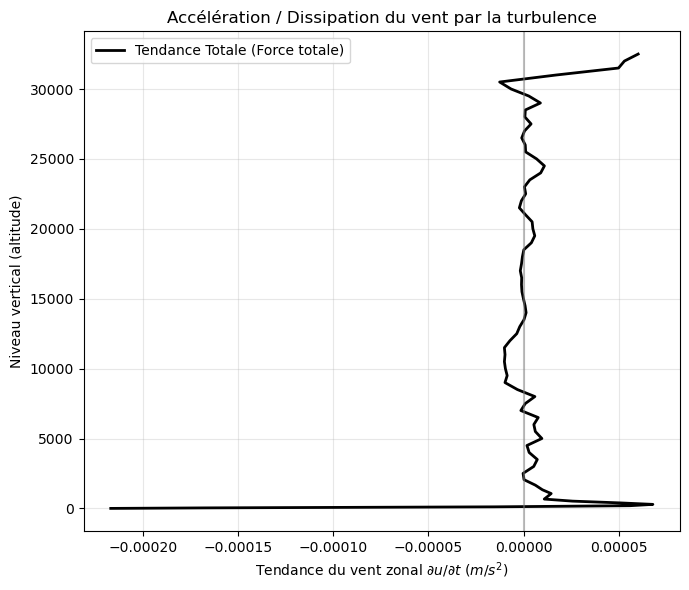

In [11]:
# =============================================================================
# 7. CALCUL DE LA DISSIPATION / TENDANCE (DÉPRIVÉE VERTICALE)
# =============================================================================
print("Calcul des tendances (pertes et gains de quantité de mouvement)...")

nom_axe_z=u.dims[1]
tendance_u_total = -flux_u_total_final.differentiate(nom_axe_z)

# =============================================================================
# 8. TRACÉ DES TENDANCES
# =============================================================================
plt.figure(figsize=(7, 6))

plt.plot(
    tendance_u_total,
    axe_z,
    label="Tendance Totale (Force totale)",
    color="black",
    linewidth=2,
)

plt.axvline(0, color="grey", linestyle="-", alpha=0.5)
plt.title("Accélération / Dissipation du vent par la turbulence")
plt.xlabel("Tendance du vent zonal $\\partial u / \\partial t$ ($m/s^2$)")
plt.ylabel(f"Niveau vertical ({nom_axe_z})")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

<>:71: SyntaxWarning: invalid escape sequence '\o'
<>:77: SyntaxWarning: invalid escape sequence '\o'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\o'
<>:77: SyntaxWarning: invalid escape sequence '\o'
<>:90: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6008/3577293447.py:71: SyntaxWarning: invalid escape sequence '\o'
  ax1.plot(flux_total_profil, axe_z, label='Flux Total $\overline{u\'w\'}$', color='black', linewidth=2.5)
/tmp/ipykernel_6008/3577293447.py:77: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_title("A. Flux vertical de quantité de mouvement ($\overline{u\'w\'}$)", fontsize=11)
/tmp/ipykernel_6008/3577293447.py:90: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title("B. Tendances du vent moyen (Force de friction : $-\partial \overline{u\'w\'}/\partial z$)", fontsize=11)


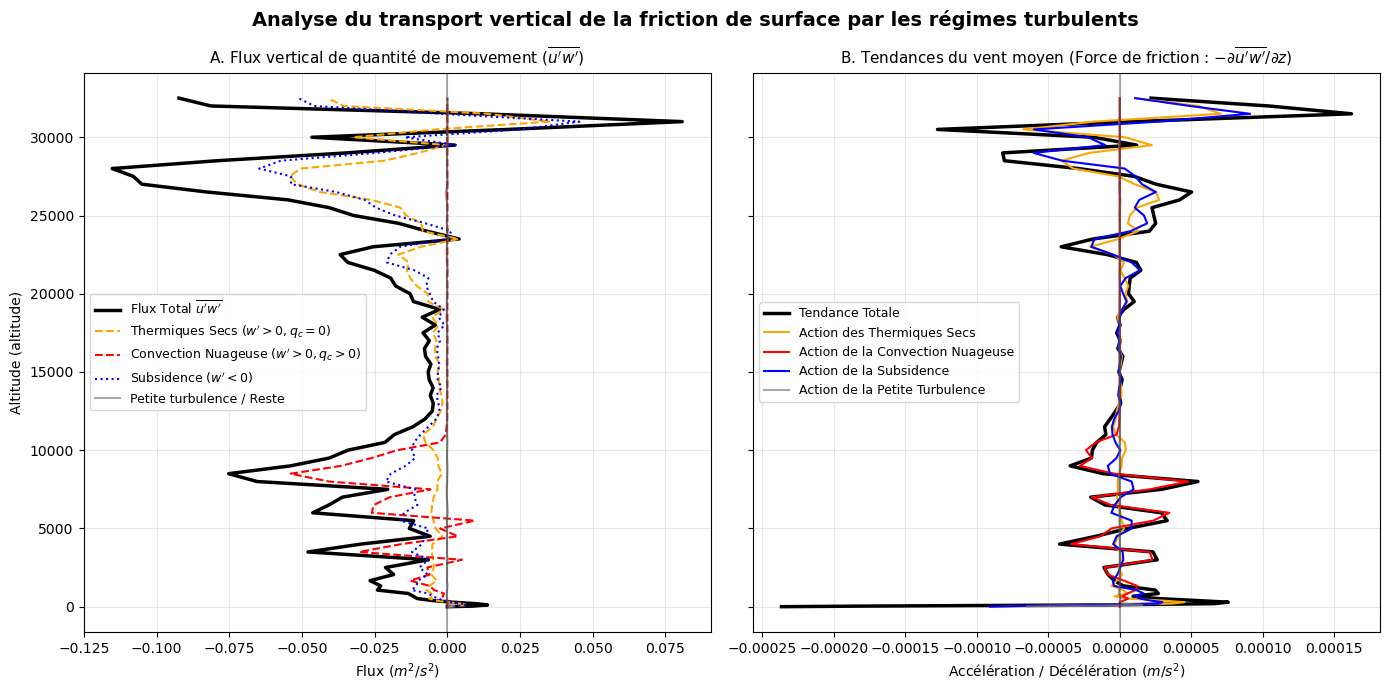

In [12]:

# Extraction des variables (on prend le premier pas de temps t=0 ici)
u = data_ua['ua'].isel(time=0)
w = data_wa['wa'].isel(time=0)
clw = data_clw['clw'].isel(time=0)
cli = data_cli['cli'].isel(time=0)

# Récupération du nom des axes 
nom_axe_z = u.dims[0]  
nom_axe_y = u.dims[1]
nom_axe_x = u.dims[2]
axe_z = u[nom_axe_z]

# eau totale nuageuse pour détecter la convection condensée
eau_nuage = clw + cli

# =============================================================================
# 2. CALCUL DES FLUCTUATIONS TURBULENTES (ANOMALIES)
# =============================================================================
# Moyenne horizontale (sur X et Y) pour obtenir l'état moyen vertical
u_moy = u.mean(dim=[nom_axe_y, nom_axe_x])
w_moy = w.mean(dim=[nom_axe_y, nom_axe_x])

# Calcul des anomalies turbulentes (Reynolds decomposition : phi' = phi - <phi>)
u_prime = u - u_moy
w_prime = w - w_moy

# Flux de quantité de mouvement résolu total
flux_total_local = u_prime * w_prime
flux_total_profil = flux_total_local.mean(dim=[nom_axe_y, nom_axe_x])

# =============================================================================
# 3. MASQUAGE PHYSIQUE : SÉPARATION DES TYPES DE TURBULENCE
# =============================================================================
# Seuil pour définir un courant vertical significatif (ex: 0.1 m/s) ou simplement > 0
seuil_w = 0.05 
seuil_nuage = 1e-5 # kg/kg

# A. Convection Nuageuse Active (Thermiques saturés / Updrafts nuageux)
masque_conv_active = (w_prime > seuil_w) & (eau_nuage > seuil_nuage)

# B. Thermiques Secs de Couche Limite (Panaches sous-nuageux / Updrafts secs)
masque_thermique_sec = (w_prime > seuil_w) & (eau_nuage <= seuil_nuage)

# C. Subsidence Environnementale (Mouvements descendants lents ou compensatoires)
masque_subsidence = (w_prime < -seuil_w)

# Calcul des flux conditionnels (Moyenne horizontale uniquement là où le masque est vrai)
flux_conv_active = flux_total_local.where(masque_conv_active).fillna(0).mean(dim=[nom_axe_y, nom_axe_x])
flux_thermique_sec = flux_total_local.where(masque_thermique_sec).fillna(0).mean(dim=[nom_axe_y, nom_axe_x])
flux_subsidence = flux_total_local.where(masque_subsidence).fillna(0).mean(dim=[nom_axe_y, nom_axe_x])

# Le reste : petite turbulence isotrope / bruits de fond
flux_petite_echelle = flux_total_profil - (flux_conv_active + flux_thermique_sec + flux_subsidence)

# =============================================================================
# 4. CALCUL DES TENDANCES (DIVERGENCE DU FLUX) : - d(u'w')/dz
# =============================================================================
# La dérivée par rapport à z donne l'accélération ou le freinage net du vent moyen
tendance_totale      = - flux_total_profil.differentiate(nom_axe_z)
tendance_conv        = - flux_conv_active.differentiate(nom_axe_z)
tendance_sec         = - flux_thermique_sec.differentiate(nom_axe_z)
tendance_subsidence  = - flux_subsidence.differentiate(nom_axe_z)
tendance_subgrid     = - flux_petite_echelle.differentiate(nom_axe_z)

# =============================================================================
# 5. VISUALISATION AVANCÉE EN DEUX PANNEAUX
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# Graphique 1 : Les Profils de Flux Covariant <u'w'>
ax1.plot(flux_total_profil, axe_z, label='Flux Total $\overline{u\'w\'}$', color='black', linewidth=2.5)
ax1.plot(flux_thermique_sec, axe_z, label='Thermiques Secs ($w\'>0, q_c=0$)', color='orange', linestyle='--')
ax1.plot(flux_conv_active, axe_z, label='Convection Nuageuse ($w\'>0, q_c>0$)', color='red', linestyle='--')
ax1.plot(flux_subsidence, axe_z, label='Subsidence ($w\'<0$)', color='blue', linestyle=':')
ax1.plot(flux_petite_echelle, axe_z, label='Petite turbulence / Reste', color='grey', alpha=0.7)
ax1.axvline(0, color='black', alpha=0.3, linestyle='-')
ax1.set_title("A. Flux vertical de quantité de mouvement ($\overline{u\'w\'}$)", fontsize=11)
ax1.set_xlabel("Flux ($m^2/s^2$)")
ax1.set_ylabel(f"Altitude ({nom_axe_z})")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=9)

# Graphique 2 : Les Tendances (Forces de friction communiquées)
ax2.plot(tendance_totale, axe_z, label='Tendance Totale', color='black', linewidth=2.5)
ax2.plot(tendance_sec, axe_z, label='Action des Thermiques Secs', color='orange')
ax2.plot(tendance_conv, axe_z, label='Action de la Convection Nuageuse', color='red')
ax2.plot(tendance_subsidence, axe_z, label='Action de la Subsidence', color='blue')
ax2.plot(tendance_subgrid, axe_z, label='Action de la Petite Turbulence', color='grey', alpha=0.7)
ax2.axvline(0, color='black', alpha=0.3, linestyle='-')
ax2.set_title("B. Tendances du vent moyen (Force de friction : $-\partial \overline{u\'w\'}/\partial z$)", fontsize=11)
ax2.set_xlabel("Accélération / Décélération ($m/s^2$)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=9)

plt.suptitle("Analyse du transport vertical de la friction de surface par les régimes turbulents", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Analyse du vent horizontal à l'état initial

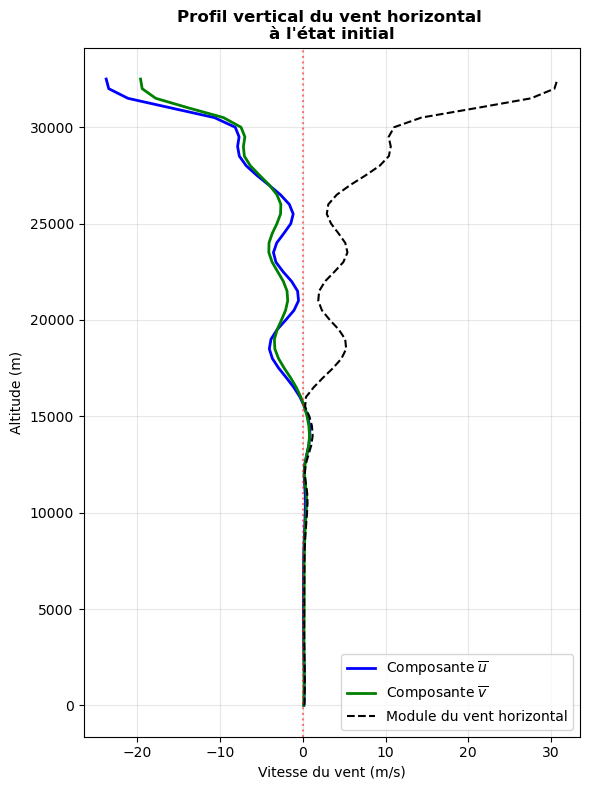

In [35]:

indices = slice(-200, None) 

u_moyen_vertical = data_ua['ua'].isel(time=indices).mean(dim=['time', 'x', 'y'])
v_moyen_vertical = data_va['va'].isel(time=indices).mean(dim=['time', 'x', 'y'])

vitesse_horizontale_moyenne = np.sqrt(u_moyen_vertical**2 + v_moyen_vertical**2)

altitude = data_ua['altitude'].values

# 3. Visualisation du profil vertical du vent moyen
plt.figure(figsize=(6, 8))
plt.plot(u_moyen_vertical, altitude, label=r'Composante $\overline{u}$', color='blue', linewidth=2)
plt.plot(v_moyen_vertical, altitude, label=r'Composante $\overline{v}$', color='green', linewidth=2)
plt.plot(vitesse_horizontale_moyenne, altitude, label='Module du vent horizontal', color='black', linestyle='--', linewidth=1.5)

plt.axvline(0, color='red', alpha=0.5, linestyle=':')
plt.title("Profil vertical du vent horizontal \nà l'état initial", fontsize=12, fontweight='bold')
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Altitude (m)")
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Analyse du vent horizontal moyen à l'état stationnaire

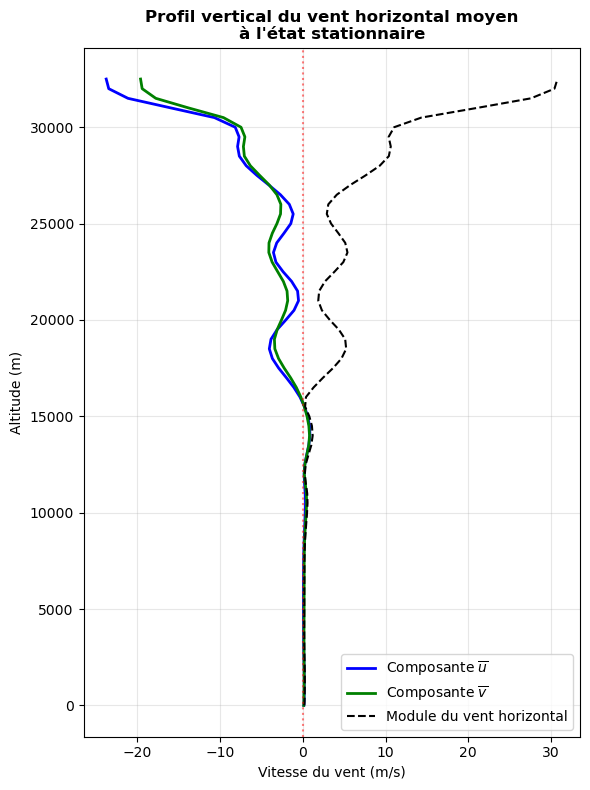

In [34]:

indices_stationnaires = slice(-200, None) 

u_moyen_vertical = data_ua['ua'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])
v_moyen_vertical = data_va['va'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])

vitesse_horizontale_moyenne = np.sqrt(u_moyen_vertical**2 + v_moyen_vertical**2)

altitude = data_ua['altitude'].values

# 3. Visualisation du profil vertical du vent moyen
plt.figure(figsize=(6, 8))
plt.plot(u_moyen_vertical, altitude, label=r'Composante $\overline{u}$', color='blue', linewidth=2)
plt.plot(v_moyen_vertical, altitude, label=r'Composante $\overline{v}$', color='green', linewidth=2)
plt.plot(vitesse_horizontale_moyenne, altitude, label='Module du vent horizontal', color='black', linestyle='--', linewidth=1.5)

plt.axvline(0, color='red', alpha=0.5, linestyle=':')
plt.title("Profil vertical du vent horizontal moyen\nà l'état stationnaire", fontsize=12, fontweight='bold')
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Altitude (m)")
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Il y a bien une source de vent artificiel car le vent horizontal moyen à l'étatstationnaire est non nul. D'où vient-il ? Il doit y avoir un équilibre entre ce vent de rappel rajouté sur les simulations RCE et le tenseur de l'équation de navier stokes correspondnat à la dérivée du flus de reynolds.

<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_6008/1174818190.py:49: SyntaxWarning: invalid escape sequence '\D'
  ax.plot(rappel_theorique_u, axe_z, label='Force de Rappel Théorique calculée ($-\Delta U / \\tau$)', color='blue', linestyle='--', linewidth=2)


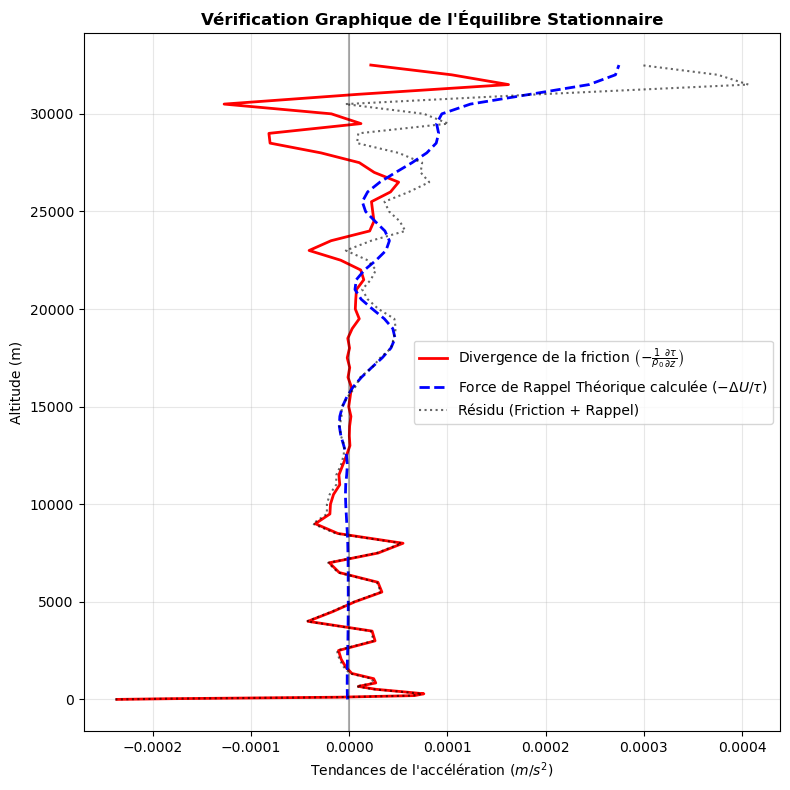

In [24]:
# 1. Définition de la période stationnaire
# On isole la fin de la simulation stabilisée (ex: les 20 derniers pas de temps)
indices_stationnaires = slice(-200, None)

# 2. Extraction de l'altitude et calcul de rho0 (masse volumique de base)
axe_z = data_ua['altitude'].values

# Pour calculer rho0, on utilise la pression (pa) et la température (ta) de base
# R_d = 287.05 J/kg/K (constante des gaz parfaits pour l'air sec)
R_d = 287.05
T_moyenne = data_ta['ta'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])
P_moyenne = data_pa['pa'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])
rho0 = P_moyenne / (R_d * T_moyenne)

# 3. Calcul des profils de vent horizontal moyen
u_moyen = data_ua['ua'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])
v_moyen = data_va['va'].isel(time=indices_stationnaires).mean(dim=['time', 'x', 'y'])

# 4. Calcul de la divergence du tenseur de Reynolds (avec intégration manuelle de rho0)
# Note : Si vos variables de tendances ('tendance_sec', etc.) sont déjà en m/s², 
# elles intègrent déjà la division par rho0. 
# Si vous repartez des flux cinématiques uw_turbulent, le calcul correct est :
# contrainte_friction = - (1.0 / rho0) * np.gradient(rho0 * uw_flux_moyen, axe_z)

# En utilisant vos variables globales existantes :
tendance_friction = (tendance_sec + tendance_conv + tendance_subsidence + tendance_subgrid)

# 5. PARAMÈTRES DU FORÇAGE REEL DU MODÈLE (À AJUSTER SELON VOTRE CONFIGURATION RCE)
# Modifiez ces valeurs selon le fichier de configuration (.NAM) de votre simulation Meso-NH
f_coriolis = 0.0          # ex: 1e-4 s^-1 si simulation hors de l'équateur
u_prescrit = 0.0          # Vent cible ou vent géostrophique ug (souvent 0 en RCE standard)
v_g = 0.0                 # Vent géostrophique vg
tau_nudging = 86400.0     # Temps de rappel en secondes (ex: 1 jour = 86400s)

# CALCUL DE TOUTE PIÈCE DU RAPPEL THÉORIQUE
# Si Nudging standard :
rappel_theorique_u = - (u_moyen - u_prescrit) / tau_nudging




# 6. GRAPHIQUE DE VÉRIFICATION
fig, ax = plt.subplots(figsize=(8, 8))

# On trace la friction calculée
ax.plot(tendance_friction, axe_z, label=r'Divergence de la friction $\left(-\frac{1}{\rho_0}\frac{\partial \tau}{\partial z}\right)$', color='red', linewidth=2)

# On trace le rappel calculé de toute pièce
ax.plot(rappel_theorique_u, axe_z, label='Force de Rappel Théorique calculée ($-\Delta U / \\tau$)', color='blue', linestyle='--', linewidth=2)

# On ajoute la somme des deux pour vérifier graphiquement si ça donne zéro
ax.plot(tendance_friction + rappel_theorique_u, axe_z, label='Résidu (Friction + Rappel)', color='black', alpha=0.6, linestyle=':')

ax.axvline(0, color='black', alpha=0.3)
ax.set_title("Vérification Graphique de l'Équilibre Stationnaire", fontsize=12, fontweight='bold')
ax.set_xlabel("Tendances de l'accélération ($m/s^2$)")
ax.set_ylabel("Altitude (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()